CNN consists of mainly four layers that are :-<pre>
1)convolutional layer 
2)relu layer
3)pooling layer <pre>
        1)max pooling
        2)average pooling</pre>
4)fully connected layer</pre>



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from keras.datasets import mnist
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
import random
np.random.seed(0)

In [3]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [4]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


<function matplotlib.pyplot.show(close=None, block=None)>

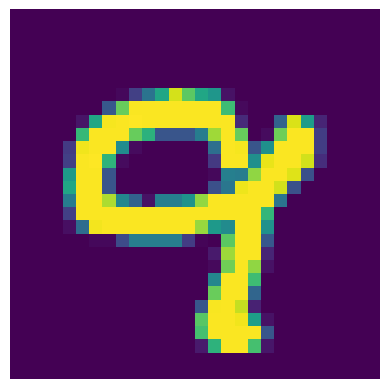

In [5]:
plt.imshow(x_train[y_train==9][1000])
plt.axis('off')
plt.show


<function matplotlib.pyplot.show(close=None, block=None)>

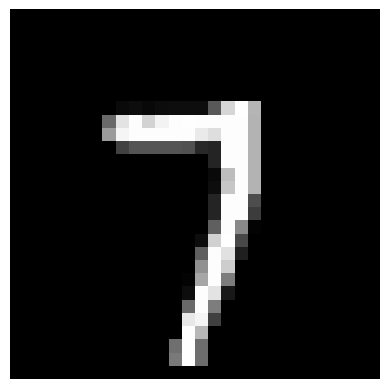

In [6]:
plt.imshow(x_train[y_train==7][4000],cmap='grey')
plt.axis('off')
plt.show


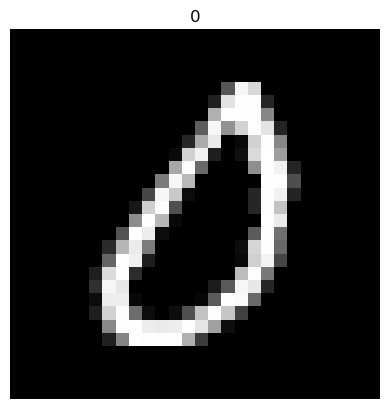

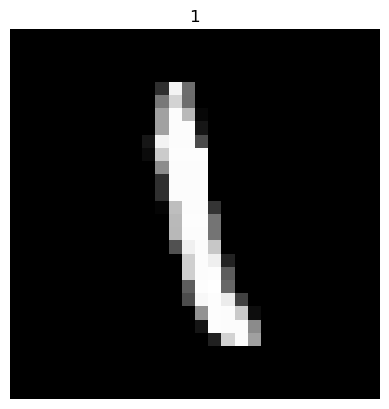

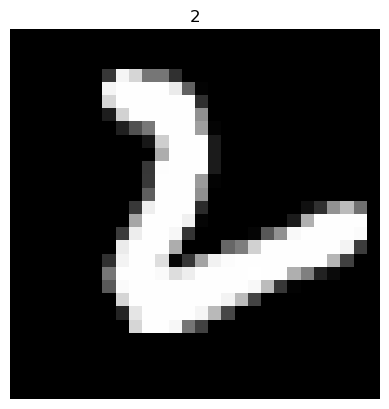

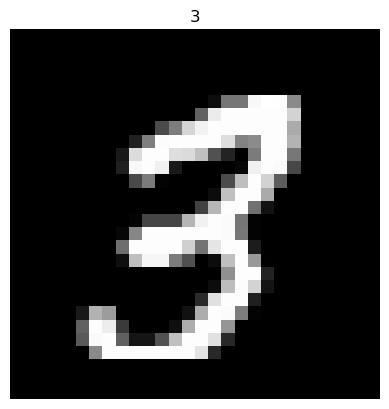

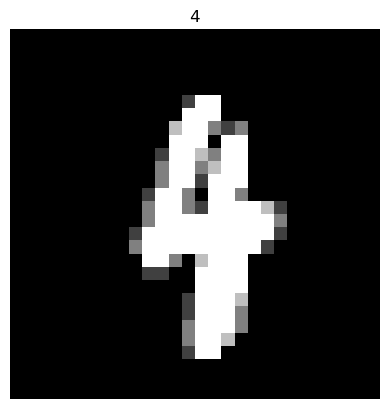

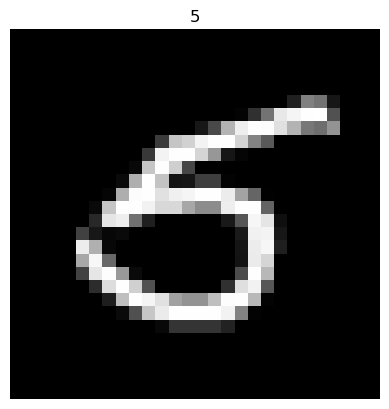

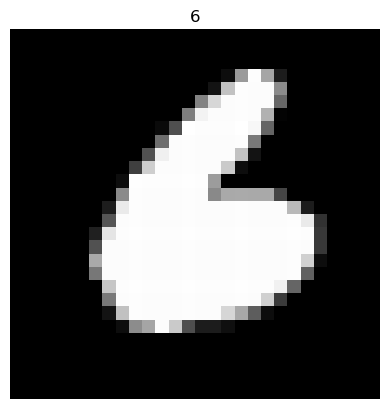

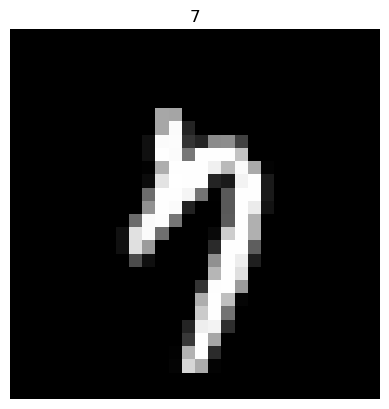

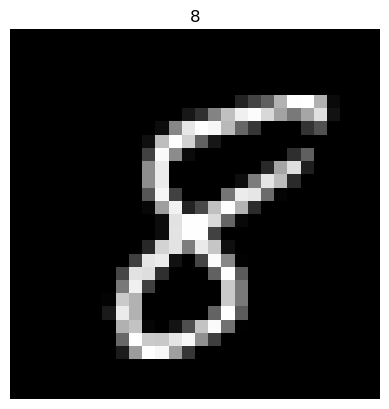

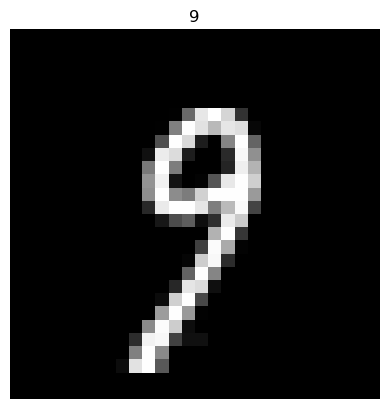

In [7]:
for i in range(0,10):
    plt.imshow(x_train[y_train==i][np.random.randint(0,5000)],cmap='gray')
    plt.title(str(i))
    plt.axis('off')
    plt.show()

In [8]:
from keras.utils import to_categorical

In [9]:
y_train=to_categorical(y_train,10)
y_test=to_categorical(y_test)


In [10]:
x_train=x_train.reshape(60000,28,28,1)
x_test=x_test.reshape(10000,28,28,1)


In [11]:
x_train=x_train/255
x_test=x_test/255

In [12]:
#CNN Models
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten

In [18]:
from keras.src.models import model
def Lenet_Model():

    model = Sequential()

    model.add(Conv2D(30, (5,5), input_shape=(28,28,1), activation='relu'))
    model.add(Conv2D(15, (3,3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))

    model.add(Flatten())

    model.add(Dense(200, activation='relu'))
    model.add(Dense(100, activation='relu'))

    model.add(Dense(10, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=0.01),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model   

In [19]:
model = Lenet_Model()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 30)     │           780 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 22, 22, 15)     │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 11, 15)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1815)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 200)            │       363,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,155 (1.48 MB)

 Trainable params: 389,155 (1.48 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
h=model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9318 - loss: 0.2253 - val_accuracy: 0.9652 - val_loss: 0.1183
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9607 - loss: 0.1399 - val_accuracy: 0.9702 - val_loss: 0.1185
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 17ms/step - accuracy: 0.9652 - loss: 0.1275 - val_accuracy: 0.9705 - val_loss: 0.1085
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 25s 15ms/step - accuracy: 0.9677 - loss: 0.1178 - val_accuracy: 0.9738 - val_loss: 0.0989
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9700 - loss: 0.1094 - val_accuracy: 0.9748 - val_loss: 0.1043
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9734 - loss: 0.1018 - val_accuracy: 0.9750 - val_loss: 0.0986
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 32s 19ms/step - accuracy: 0.9722 - loss: 0.1040 - val_accuracy: 0.9717 - val_loss: 0.1373
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9753 -

In [21]:
pred= model.predict(x_test)
print(pred[0])      

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
[1.0221663e-14 4.4448334e-06 3.6218794e-04 2.5188774e-06 1.2012970e-11
 1.2984180e-16 0.0000000e+00 9.9940944e-01 2.8415345e-12 2.2144949e-04]


In [22]:
pred=np.argmax(pred,axis=1)
pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))